# 02. 오토인코더 + MTS 데이터 증강 기본 구현

- STS / MTS / FT 학습 데이터셋 생성 (정보 누수 방지 규칙 포함)
- 타임스케일당 1200개 샘플 고정
- 1-hidden-layer 오토인코더 (PyTorch)
- 단일 기준일에서 학습 → reconstruction RMSE → 산점도 확인

논문 하이퍼파라미터: epochs 50, batch 128, Adam, middle 1층 (linear/tanh), output linear, 압축률 C=50%

In [1]:
# 공통 설정 (00_environment_check.ipynb 와 동일)
from pathlib import Path
import random
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

ROOT = Path("..").resolve()
DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
SAMPLE_DIR = DATA_DIR / "sample"
REPORT_DIR = ROOT / "reports"
FIG_DIR = REPORT_DIR / "figures"
RESULT_DIR = REPORT_DIR / "results"
for p in [RAW_DIR, PROCESSED_DIR, SAMPLE_DIR, FIG_DIR, RESULT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cuda


## Cell 1: processed 수익률 데이터 로드

In [2]:
# 01_data_and_returns.ipynb 에서 저장한 processed 데이터 로드
with open(PROCESSED_DIR / "stock_panel.pkl", "rb") as fh:
    panel = pickle.load(fh)

prices = panel["prices"]
returns_by_tau = panel["returns_by_tau"]
norm_by_tau = panel["norm_by_tau"]
sigma_by_tau = panel["sigma_by_tau"]
TAU_MAX = max(returns_by_tau.keys())
dates = prices.index
print("assets:", prices.shape[1], "| days:", prices.shape[0], "| tau: 1..%d" % TAU_MAX)

assets: 100 | days: 3000 | tau: 1..20


## Cell 2: 학습 시점 생성 (`build_train_times`)

정보 누수 방지: 현재 시점 t의 tau-수익률과 기간이 겹치는 최근 `tau-1`개 시점을 제외한다.

```
t_train_tau(t) = { t-(tau-1)-1, ..., t-(tau-1)-1200 }
```

In [3]:
LOOKBACK = 1200  # 논문: 타임스케일당 학습 샘플 수 고정


def build_train_positions(t_pos: int, tau: int, lookback: int = LOOKBACK) -> list:
    # t_train_tau(t) = { t-(tau-1)-1, ..., t-(tau-1)-lookback }
    # 현재 시점 수익률과 기간이 겹치는 최근 tau-1개 시점을 제외해 정보 누수를 방지
    end = t_pos - (tau - 1)          # exclusive
    start = end - lookback
    if start < tau:
        raise ValueError(f"t_pos={t_pos}, tau={tau}: 학습 구간이 데이터 범위를 벗어남")
    return list(range(start, end))


def valid_assets(norm_by_tau: dict, t_pos: int, tau_star: int, lookback: int = LOOKBACK) -> list:
    # 학습 구간 + 현재 시점 모두에서 결측이 없는 자산만 사용 (날짜별 investable universe)
    ok = None
    for tau in range(1, tau_star + 1):
        pos = build_train_positions(t_pos, tau, lookback) + [t_pos]
        good = norm_by_tau[tau].iloc[pos].notna().all(axis=0)
        ok = good if ok is None else (ok & good)
    return list(ok.index[ok])


def extract_matrix(norm_returns: pd.DataFrame, positions: list, assets: list) -> np.ndarray:
    X = norm_returns.iloc[positions][assets].to_numpy(dtype=np.float32)
    if np.isnan(X).any():
        raise ValueError("학습 행렬에 NaN 존재 - universe 처리 필요")
    return X


def build_sts_dataset(t_pos, tau_star, norm_by_tau, assets, lookback=LOOKBACK):
    # STS: tau = tau_star 만 사용
    pos = build_train_positions(t_pos, tau_star, lookback)
    return extract_matrix(norm_by_tau[tau_star], pos, assets)


def build_mts_dataset(t_pos, tau_star, norm_by_tau, assets, lookback=LOOKBACK):
    # MTS: tau = 1..tau_star 전부 사용 -> 샘플 수 = lookback * tau_star
    mats = [
        extract_matrix(norm_by_tau[tau], build_train_positions(t_pos, tau, lookback), assets)
        for tau in range(1, tau_star + 1)
    ]
    return np.vstack(mats)


def build_ft_datasets(t_pos, tau_star, norm_by_tau, assets, lookback=LOOKBACK):
    # FT: tau = 1..tau_star-1 로 pre-train 후 tau_star 로 fine-tune
    X_ft = build_sts_dataset(t_pos, tau_star, norm_by_tau, assets, lookback)
    if tau_star == 1:
        return None, X_ft
    mats = [
        extract_matrix(norm_by_tau[tau], build_train_positions(t_pos, tau, lookback), assets)
        for tau in range(1, tau_star)
    ]
    return np.vstack(mats), X_ft

In [4]:
# 누수 방지 규칙 단위 테스트 (계획서 8. 테스트 계획)
pos = build_train_positions(t_pos=1500, tau=20, lookback=1200)
assert len(pos) == 1200
assert max(pos) == 1500 - (20 - 1) - 1      # 가장 최근 학습 시점
assert min(pos) == 1500 - (20 - 1) - 1200   # 가장 오래된 학습 시점
assert 1500 - 19 not in pos                  # 겹치는 구간은 제외되어야 함

pos1 = build_train_positions(t_pos=1500, tau=1, lookback=1200)
assert max(pos1) == 1499                     # tau=1 은 직전 시점까지 사용
print("build_train_positions 누수 방지 검증 통과")

build_train_positions 누수 방지 검증 통과


## Cell 3: STS / MTS / FT dataset builder 검증

In [5]:
T_DEMO = 1500        # 단일 기준일 (index position)
TAU_STAR = 20

assets = valid_assets(norm_by_tau, T_DEMO, TAU_STAR)
N_ASSETS = len(assets)
print("universe:", N_ASSETS, "assets")

X_sts = build_sts_dataset(T_DEMO, TAU_STAR, norm_by_tau, assets)
X_mts = build_mts_dataset(T_DEMO, TAU_STAR, norm_by_tau, assets)
X_pre, X_ft = build_ft_datasets(T_DEMO, TAU_STAR, norm_by_tau, assets)

assert X_sts.shape == (1200, N_ASSETS)
assert X_mts.shape == (1200 * TAU_STAR, N_ASSETS)   # 샘플 수 = 1200 * tau_star
assert X_pre.shape == (1200 * (TAU_STAR - 1), N_ASSETS)
assert X_ft.shape == (1200, N_ASSETS)
print("STS :", X_sts.shape)
print("MTS :", X_mts.shape)
print("FT  : pre", X_pre.shape, "/ ft", X_ft.shape)

universe: 100 assets
STS : (1200, 100)
MTS : (24000, 100)
FT  : pre (22800, 100) / ft (1200, 100)


## Cell 4: PyTorch AutoEncoder

In [6]:
class AutoEncoder(nn.Module):
    # Input(N) -> Dense(M, middle_activation) -> Dense(N, linear),  M = N * C
    def __init__(self, n_assets, compression_ratio=0.5, middle_activation="linear"):
        super().__init__()
        n_hidden = max(1, int(n_assets * compression_ratio))
        act = nn.Identity() if middle_activation == "linear" else nn.Tanh()
        self.encoder = nn.Sequential(nn.Linear(n_assets, n_hidden), act)
        self.decoder = nn.Linear(n_hidden, n_assets)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

## Cell 5: 학습 / 복원 / RMSE 함수

In [7]:
def train_autoencoder(X_train: np.ndarray, config: dict, model: nn.Module = None) -> nn.Module:
    device = config["device"]
    torch.manual_seed(config["seed"])
    if model is None:
        model = AutoEncoder(
            X_train.shape[1],
            config["compression_ratio"],
            config["middle_activation"],
        ).to(device)
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=config["lr"])
    loss_fn = nn.MSELoss()
    X = torch.tensor(X_train, dtype=torch.float32, device=device)
    n, bs = X.shape[0], config["batch_size"]
    gen = torch.Generator().manual_seed(config["seed"])
    for _ in range(config["epochs"]):
        perm = torch.randperm(n, generator=gen).to(device)
        for i in range(0, n, bs):
            xb = X[perm[i : i + bs]]
            opt.zero_grad()
            loss = loss_fn(model(xb), xb)
            loss.backward()
            opt.step()
    return model


def pretrain_and_finetune(X_pre, X_ft, config):
    if X_pre is None:
        return train_autoencoder(X_ft, config)
    model = train_autoencoder(X_pre, config)
    return train_autoencoder(X_ft, config, model=model)


def reconstruct(model: nn.Module, X: np.ndarray) -> np.ndarray:
    device = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        out = model(torch.tensor(X, dtype=torch.float32, device=device))
    return out.cpu().numpy()


def compute_rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

## Cell 6: 단일 기준일 t에서 MTS 학습 실행

In [8]:
import time

CONFIG = {
    "epochs": 50,
    "batch_size": 128,
    "lr": 1e-3,
    "compression_ratio": 0.5,
    "middle_activation": "linear",
    "seed": SEED,
    "device": DEVICE,
}

t0 = time.time()
model_mts = train_autoencoder(X_mts, CONFIG)
print(f"MTS 학습 완료: {time.time() - t0:.1f}s (samples={X_mts.shape[0]})")

t0 = time.time()
model_sts = train_autoencoder(X_sts, CONFIG)
print(f"STS 학습 완료: {time.time() - t0:.1f}s (samples={X_sts.shape[0]})")

MTS 학습 완료: 8.0s (samples=24000)


STS 학습 완료: 0.4s (samples=1200)


## Cell 7: reconstruction RMSE (train / test 시점)

In [9]:
# 테스트: 기준일 t 의 tau_star 정규화 수익률 벡터 (학습에 사용되지 않음)
x_test = norm_by_tau[TAU_STAR].iloc[T_DEMO][assets].to_numpy(dtype=np.float32)[None, :]

rows = []
for name, model in [("STS", model_sts), ("MTS", model_mts)]:
    rmse_train = compute_rmse(X_sts, reconstruct(model, X_sts))
    rmse_test = compute_rmse(x_test, reconstruct(model, x_test))
    rows.append({"model": name, "rmse_train(tau*)": rmse_train, "rmse_test(t)": rmse_test})

pd.DataFrame(rows).set_index("model").round(4)

,rmse_train(tau*),rmse_test(t)
model,,
STS,0.3797,0.6331
MTS,0.3706,0.5252


## Cell 8: realized vs reconstructed 산점도

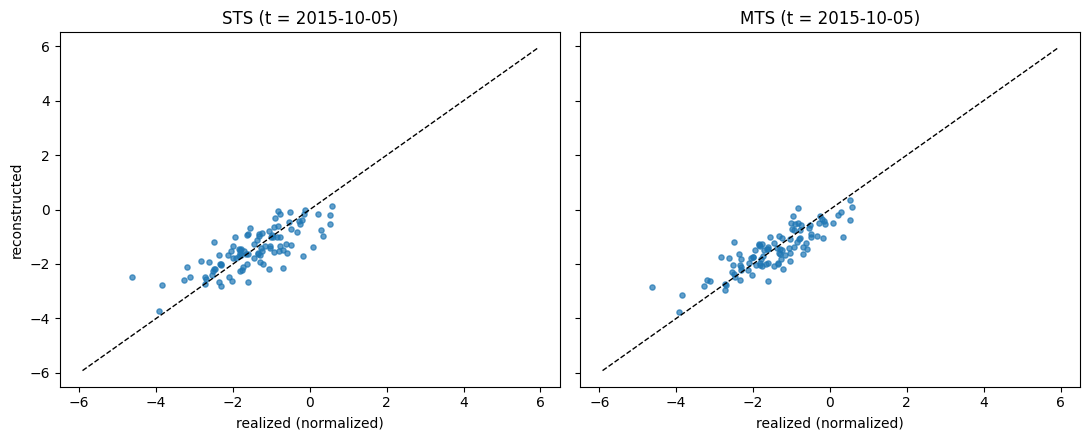

In [10]:
x_hat_mts = reconstruct(model_mts, x_test)[0]
x_hat_sts = reconstruct(model_sts, x_test)[0]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, (name, x_hat) in zip(axes, [("STS", x_hat_sts), ("MTS", x_hat_mts)]):
    ax.scatter(x_test[0], x_hat, s=14, alpha=0.7)
    lim = np.percentile(np.abs(x_test), 99) * 1.5
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=1)
    ax.set_title(f"{name} (t = {dates[T_DEMO].date()})")
    ax.set_xlabel("realized (normalized)")
axes[0].set_ylabel("reconstructed")
plt.tight_layout()
plt.savefig(FIG_DIR / "reconstruction_scatter.png", dpi=120)
plt.show()